In [2]:
!pip install protobuf==6.31.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.1/321.1 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.31.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.31.1 which is incompatible.


In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)
print("TFDS Load Available:", hasattr(tfds, "load"))

TensorFlow Version: 2.20.0
TFDS Load Available: True


In [4]:
def preprocess_data(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.transpose(image)
    label = label - 1
    return image, label

In [5]:
train_split, test_split = tfds.load('emnist/letters', split=['train', 'test'], as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.DAWOJ4_3.1.0/emnist-train.tfrecord-[0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.DAWOJ4_3.1.0/emnist-test.tfrecord-[0-9][0-9][0-9…

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.


In [6]:
BATCH_SIZE = 32
train_ds = train_split.map(preprocess_data).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_split.map(preprocess_data).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(26, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227,098 (887.10 KB)

 Trainable params: 227,098 (887.10 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)

Epoch 1/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 105s 36ms/step - accuracy: 0.8233 - loss: 0.5631 - val_accuracy: 0.8957 - val_loss: 0.3131
Epoch 2/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 91s 33ms/step - accuracy: 0.9019 - loss: 0.2989 - val_accuracy: 0.9039 - val_loss: 0.2751
Epoch 3/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 142s 33ms/step - accuracy: 0.9175 - loss: 0.2436 - val_accuracy: 0.9097 - val_loss: 0.2625
Epoch 4/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 87s 31ms/step - accuracy: 0.9282 - loss: 0.2107 - val_accuracy: 0.9164 - val_loss: 0.2434
Epoch 5/5
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 84s 30ms/step - accuracy: 0.9350 - loss: 0.1857 - val_accuracy: 0.9219 - val_loss: 0.2317


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


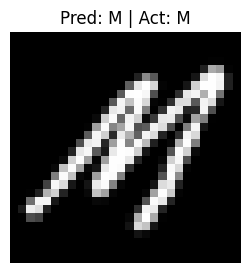

Predicted: M
Actual: M


In [9]:
for images, labels in test_ds.take(1):
    predictions = model.predict(images)
    predicted_index = np.argmax(predictions[0])
    actual_index = labels[0].numpy()

    predicted_char = chr(predicted_index + ord('A'))
    actual_char = chr(actual_index + ord('A'))

    plt.figure(figsize=(3,3))
    plt.imshow(images[0].numpy().squeeze(), cmap='gray')
    plt.title(f"Pred: {predicted_char} | Act: {actual_char}")
    plt.axis('off')
    plt.show()

    print(f"Predicted: {predicted_char}")
    print(f"Actual: {actual_char}")
    break

In [10]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

463/463 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9219 - loss: 0.2317
Final Test Accuracy: 92.19%
Final Test Loss: 0.2317


In [11]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

target_names = [chr(i + ord('A')) for i in range(26)]
print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

           A       0.91      0.96      0.93       800
           B       0.97      0.95      0.96       800
           C       0.96      0.97      0.97       800
           D       0.98      0.91      0.94       800
           E       0.97      0.95      0.96       800
           F       0.97      0.96      0.97       800
           G       0.89      0.81      0.84       800
           H       0.94      0.94      0.94       800
           I       0.71      0.83      0.77       800
           J       0.96      0.94      0.95       800
           K       0.98      0.96      0.97       800
           L       0.80      0.67      0.73       800
           M       0.98      0.99      0.98       800
           N       0.96      0.96      0.96       800
           O       0.95      0.97      0.96       800
           P       0.97      0.98      0.98       800
           Q       0.86      0.86      0.86       800
           R       0.98    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
from google.colab import files
import os

uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Uploaded file: {filename}")

Saving WhatsApp Image 2026-07-03 at 12.51.52 PM.jpeg to WhatsApp Image 2026-07-03 at 12.51.52 PM.jpeg
Uploaded file: WhatsApp Image 2026-07-03 at 12.51.52 PM.jpeg


In [29]:
def preprocess_custom_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=1)
    img = tf.image.resize(img, [28, 28])
    img = tf.cast(img, tf.float32) / 255.0

    # Background check: Agar background white hai toh invert karein
    if tf.reduce_mean(img) > 0.5:
        img = 1.0 - img

    img = tf.expand_dims(img, axis=0)
    return img

custom_image = preprocess_custom_image(filename)
print("Custom image processed and reshaped to:", custom_image.shape)

Custom image processed and reshaped to: (1, 28, 28, 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


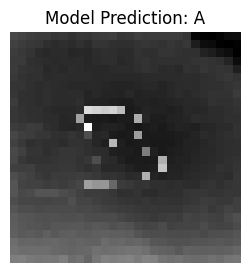

📊 Model predicted letter: A


In [31]:
custom_prediction = model.predict(custom_image)
predicted_idx = np.argmax(custom_prediction[0])
predicted_letter = chr(predicted_idx + ord('A'))

plt.figure(figsize=(3,3))
plt.imshow(custom_image[0].numpy().squeeze(), cmap='gray')
plt.title(f"Model Prediction: {predicted_letter}")
plt.axis('off')
plt.show()

print(f"📊 Model predicted letter: {predicted_letter}")